In [55]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

print("✅ All imports ready!")

✅ All imports ready!


In [56]:
# Create directory and save parameters
from pathlib import Path
import json

# Create results folder
Path('../results').mkdir(parents=True, exist_ok=True)

# Your parameters from the GARCH output
params = {
    'pre_crisis_2008': {
        'omega': 0.000161,
        'alpha': 0.0000,
        'gamma': 0.1359,
        'beta': 0.9205,
        'persistence': 0.9884,
        'period': '1997-2007',
        'description': 'Normal market conditions before 2008 crisis'
    },
    'crisis_2008': {
        'omega': 0.000284,  
        'alpha': 0.0000,
        'gamma': 0.1301,
        'beta': 0.9199,
        'persistence': 0.9849,
        'period': '2007-2009',
        'description': '2008 financial crisis'
    }, 
    'pre-crisis_Covid': {
        'omega': 0.035730,  
        'alpha': 0.0000,
        'gamma': 0.2793,
        'beta': 0.8161,
        'persistence': 0.9558,
        'period': '2010-2019',
        'description': 'Normal Market condition before COVID crisis'
    }, 
    'Covid_Crisis': { 
        'omega': 0.114953,  
        'alpha': 0.1762,
        'gamma': 0.3328,
        'beta': 0.6238,
        'persistence': 0.9664,
        'period': '2020-2021',
        'description': 'COVID crisis'

    }
}
# Save
with open('../results/garch_params.json', 'w') as f:
    json.dump(params, f, indent=4)

print("✅ garch_params.json saved to results/")
print("   Location:", Path('../results/garch_params.json').resolve())

✅ garch_params.json saved to results/
   Location: /Users/bidisabiswas/PycharmProjects/Master-Thesis-AI-Robustness/thesis-ai-robustness/results/garch_params.json


In [57]:
# Load parameters saved from your GARCH analysis
with open('../results/garch_params.json', 'r') as f:
    params = json.load(f)

# Extract pre-crisis parameters (these are your "normal market" dynamics)
pre_crisis = params['pre_crisis_2008']  

print("Loaded GARCH parameters:")
print(f"  ω (omega)     = {pre_crisis['omega']:.6f}")
print(f"  α (alpha)     = {pre_crisis['alpha']:.4f}")
print(f"  γ (gamma)     = {pre_crisis['gamma']:.4f}")
print(f"  β (beta)      = {pre_crisis['beta']:.4f}")
print(f"  Persistence   = {pre_crisis['persistence']:.4f}")

Loaded GARCH parameters:
  ω (omega)     = 0.000161
  α (alpha)     = 0.0000
  γ (gamma)     = 0.1359
  β (beta)      = 0.9205
  Persistence   = 0.9884


In [58]:
# Load parameters saved from your GARCH analysis
with open('../results/garch_params.json', 'r') as f:
    params = json.load(f)

# Extract crisis parameters (these are your "normal market" dynamics)

crisis = params['crisis_2008']  

print("Loaded GARCH parameters:")
print(f"  ω (omega)     = {crisis['omega']:.6f}")
print(f"  α (alpha)     = {crisis['alpha']:.4f}")
print(f"  γ (gamma)     = {crisis['gamma']:.4f}")
print(f"  β (beta)      = {crisis['beta']:.4f}")
print(f"  Persistence   = {crisis['persistence']:.4f}")

Loaded GARCH parameters:
  ω (omega)     = 0.000284
  α (alpha)     = 0.0000
  γ (gamma)     = 0.1301
  β (beta)      = 0.9199
  Persistence   = 0.9849


In [59]:
# Load parameters saved from your GARCH analysis
with open('../results/garch_params.json', 'r') as f:
    params = json.load(f)

# Extract crisis parameters (these are your "normal market" dynamics)

Pre_crisis_Covid = params['pre-crisis_Covid']  

print("Loaded GARCH parameters:")
print(f"  ω (omega)     = {Pre_crisis_Covid['omega']:.6f}")
print(f"  α (alpha)     = {Pre_crisis_Covid['alpha']:.4f}")
print(f"  γ (gamma)     = {Pre_crisis_Covid['gamma']:.4f}")
print(f"  β (beta)      = {Pre_crisis_Covid['beta']:.4f}")
print(f"  Persistence   = {Pre_crisis_Covid['persistence']:.4f}")

Loaded GARCH parameters:
  ω (omega)     = 0.035730
  α (alpha)     = 0.0000
  γ (gamma)     = 0.2793
  β (beta)      = 0.8161
  Persistence   = 0.9558


In [60]:
# Load parameters saved from your GARCH analysis
with open('../results/garch_params.json', 'r') as f:
    params = json.load(f)

# Extract crisis parameters (these are your "normal market" dynamics)

crisis_Covid = params['Covid_Crisis']  

print("Loaded GARCH parameters:")
print(f"  ω (omega)     = {crisis_Covid['omega']:.6f}")
print(f"  α (alpha)     = {crisis_Covid['alpha']:.4f}")
print(f"  γ (gamma)     = {crisis_Covid['gamma']:.4f}")
print(f"  β (beta)      = {crisis_Covid['beta']:.4f}")
print(f"  Persistence   = {crisis_Covid['persistence']:.4f}")

Loaded GARCH parameters:
  ω (omega)     = 0.114953
  α (alpha)     = 0.1762
  γ (gamma)     = 0.3328
  β (beta)      = 0.6238
  Persistence   = 0.9664


Test returns shape: (100, 252)
Expected: (100, 252)

Mean return across all paths: 0.000443
Std deviation across all paths: 0.111387
Mean volatility: 0.0125


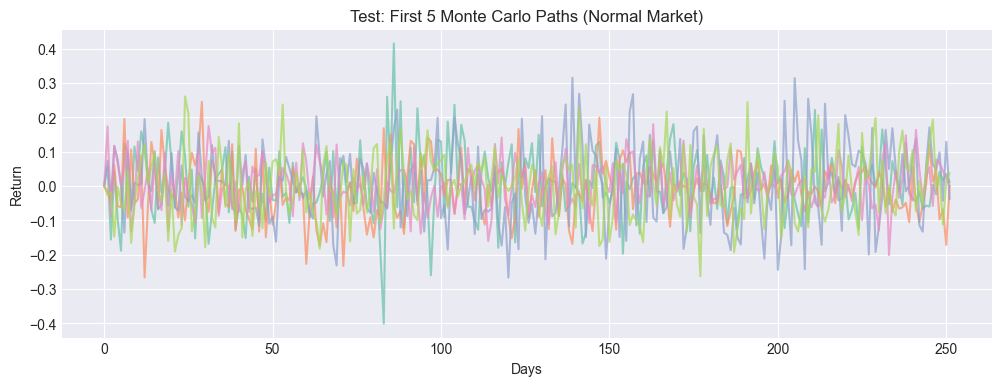

In [61]:
# Test with 100 paths first
test_returns, test_vol = generate_gjr_garch_paths(
    pre_crisis['omega'],
    pre_crisis['alpha'],
    pre_crisis['gamma'],
    pre_crisis['beta'],
    n_paths=100,
    n_days=252,
    shock_multiplier=1.0
)

print(f"Test returns shape: {test_returns.shape}")
print(f"Expected: (100, 252)")
print(f"\nMean return across all paths: {test_returns.mean():.6f}")
print(f"Std deviation across all paths: {test_returns.std():.6f}")
print(f"Mean volatility: {test_vol.mean():.4f}")

# Plot first 5 test paths
plt.figure(figsize=(12, 4))
for i in range(5):
    plt.plot(test_returns[i, :], alpha=0.7)
plt.title('Test: First 5 Monte Carlo Paths (Normal Market)')
plt.xlabel('Days')
plt.ylabel('Return')
plt.show()

In [66]:
def generate_gjr_garch_paths(omega, alpha, gamma, beta, 
                                        n_paths=10000, 
                                        n_days=252, 
                                        shock_multiplier=1.0,
                                        random_seed=42):
    """
    Generate Monte Carlo paths following GJR-GARCH process.
    
    Parameters:
    -----------
    omega, alpha, gamma, beta : GARCH parameters from estimation
    n_paths : number of paths to generate
    n_days : number of days per path
    shock_multiplier : multiplier for crisis scenarios (e.g., 2.5 for 2008-style)
    random_seed : for reproducibility
    """
    np.random.seed(random_seed)
    
    # Scale omega for crisis scenarios (this is the main driver of higher volatility)
    omega_adj = omega * shock_multiplier
    
    # Keep other parameters stable (they represent structural market behavior)
    alpha_adj = alpha
    gamma_adj = gamma
    beta_adj = beta
    
    # Initialize arrays
    returns = np.zeros((n_paths, n_days))
    sigma2 = np.zeros((n_paths, n_days))
    
    # Initial variance (unconditional)
    denom = 1 - alpha_adj - beta_adj - gamma_adj/2
    if denom <= 0:
        denom = 0.05  # Fallback for numerical stability
    sigma2[:, 0] = omega_adj / denom
    
    for t in range(1, n_days):
        # Random shocks
        z = np.random.normal(0, 1, n_paths)
        
        # Past shock squared
        epsilon2 = returns[:, t-1] ** 2
        
        # Indicator for bad news (negative returns)
        I = (returns[:, t-1] < 0).astype(float)
        
        # GJR-GARCH variance equation
        sigma2[:, t] = (omega_adj + 
                        alpha_adj * epsilon2 + 
                        gamma_adj * I * epsilon2 + 
                        beta_adj * sigma2[:, t-1])
        
        # Floor to prevent negative variance (but NO cap)
        sigma2[:, t] = np.maximum(sigma2[:, t], 1e-10)
        
        # Generate returns
        returns[:, t] = np.sqrt(sigma2[:, t]) * z
    
    return returns, sigma2

In [67]:
# Define your scenarios with shock multipliers
scenarios = {
    'normal': {
        'shock_multiplier': 1.0,
        'color': 'blue',
        'description': 'Normal market conditions'
    },
    'crisis_2008': {
        'shock_multiplier': 2.5,
        'color': 'red',
        'description': '2008-style financial crisis'
    },
    'crisis_covid': {
        'shock_multiplier': 1.8,
        'color': 'orange',
        'description': 'COVID-19 pandemic crisis'
    },
    'synthetic_extreme': {
        'shock_multiplier': 3.0,
        'color': 'purple',
        'description': 'Synthetic extreme crisis (beyond historical)'
    }
}

print("Scenarios defined:")
for name, config in scenarios.items():
    print(f"  {name}: {config['shock_multiplier']}x → {config['description']}")

Scenarios defined:
  normal: 1.0x → Normal market conditions
  crisis_2008: 2.5x → 2008-style financial crisis
  crisis_covid: 1.8x → COVID-19 pandemic crisis
  synthetic_extreme: 3.0x → Synthetic extreme crisis (beyond historical)


In [68]:
# Parameters
n_paths = 10000
n_days = 252

# Dictionary to store all paths
all_paths = {}

for name, config in scenarios.items():
    print(f"\nGenerating {name} scenario (shock_multiplier = {config['shock_multiplier']}x)...")
    
    returns, volatility = generate_gjr_garch_paths(
        pre_crisis['omega'],
        pre_crisis['alpha'],
        pre_crisis['gamma'],
        pre_crisis['beta'],
        n_paths=n_paths,
        n_days=n_days,
        shock_multiplier=config['shock_multiplier']
    )
    
    all_paths[name] = {
        'returns': returns,
        'volatility': volatility,
        'description': config['description']
    }
    
    print(f"  ✅ Generated {returns.shape[0]:,} paths of {returns.shape[1]} days")
    print(f"     Mean volatility: {volatility.mean():.4f}%")
    print(f"     Max volatility:  {volatility.max():.4f}%")

print("\n✅ All scenarios generated!")


Generating normal scenario (shock_multiplier = 1.0x)...
  ✅ Generated 10,000 paths of 252 days
     Mean volatility: 0.0137%
     Max volatility:  1.3525%

Generating crisis_2008 scenario (shock_multiplier = 2.5x)...
  ✅ Generated 10,000 paths of 252 days
     Mean volatility: 0.0343%
     Max volatility:  3.3812%

Generating crisis_covid scenario (shock_multiplier = 1.8x)...
  ✅ Generated 10,000 paths of 252 days
     Mean volatility: 0.0247%
     Max volatility:  2.4345%

Generating synthetic_extreme scenario (shock_multiplier = 3.0x)...
  ✅ Generated 10,000 paths of 252 days
     Mean volatility: 0.0412%
     Max volatility:  4.0574%

✅ All scenarios generated!


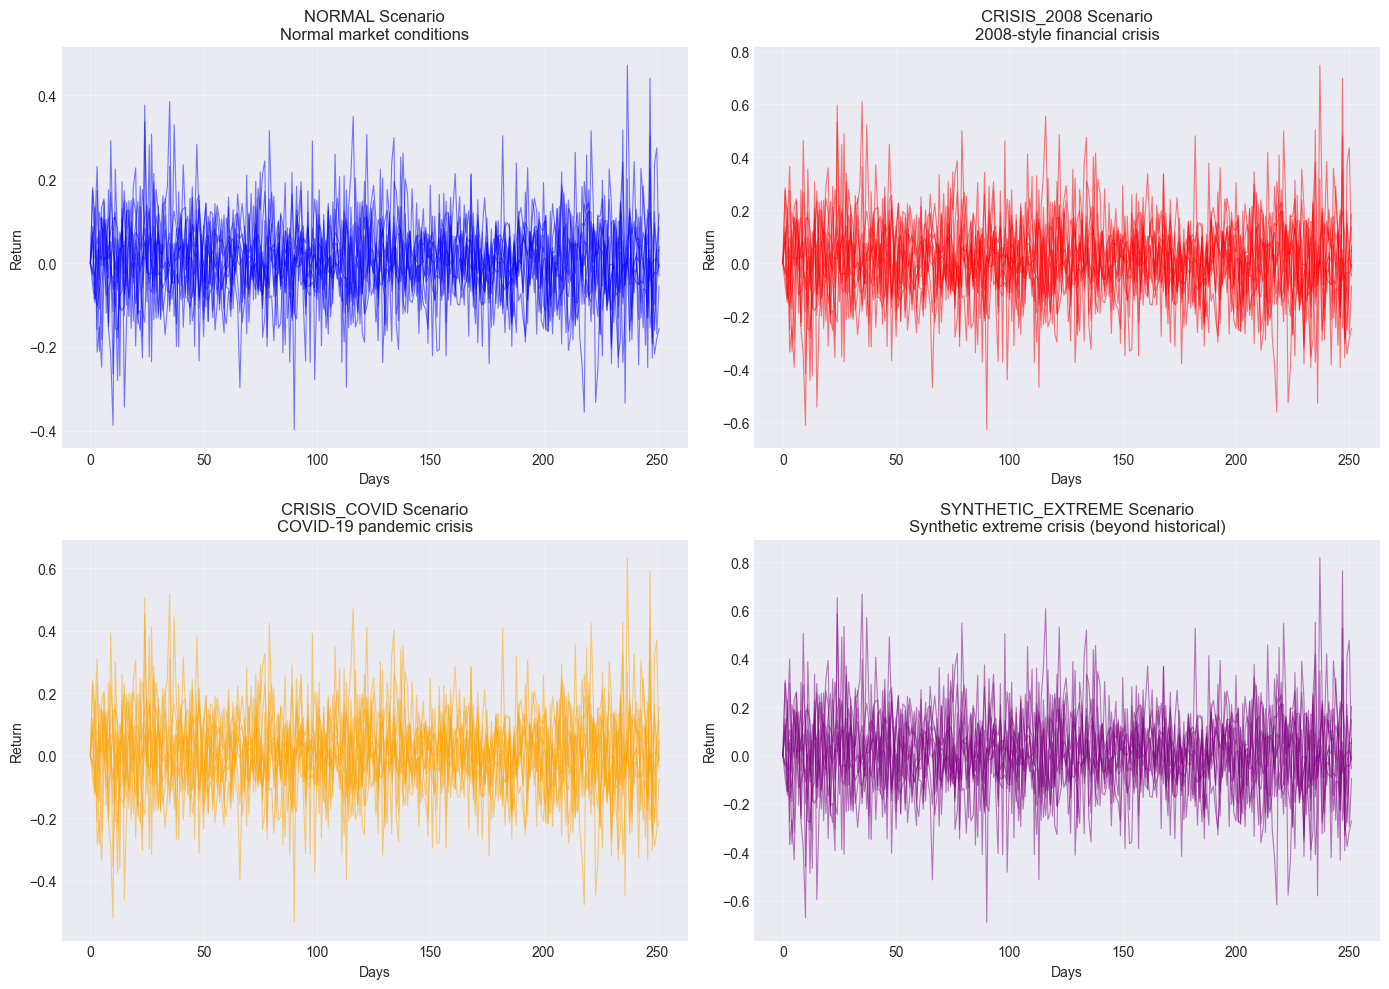

In [69]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (name, data) in enumerate(all_paths.items()):
    ax = axes[idx]
    
    # Plot first 10 paths
    for i in range(10):
        ax.plot(data['returns'][i, :], alpha=0.5, linewidth=0.8, 
                color=scenarios[name]['color'])
    
    ax.set_title(f"{name.upper()} Scenario\n{scenarios[name]['description']}", fontsize=12)
    ax.set_xlabel('Days')
    ax.set_ylabel('Return')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/figures/mc_sample_paths.png', dpi=150)
plt.show()

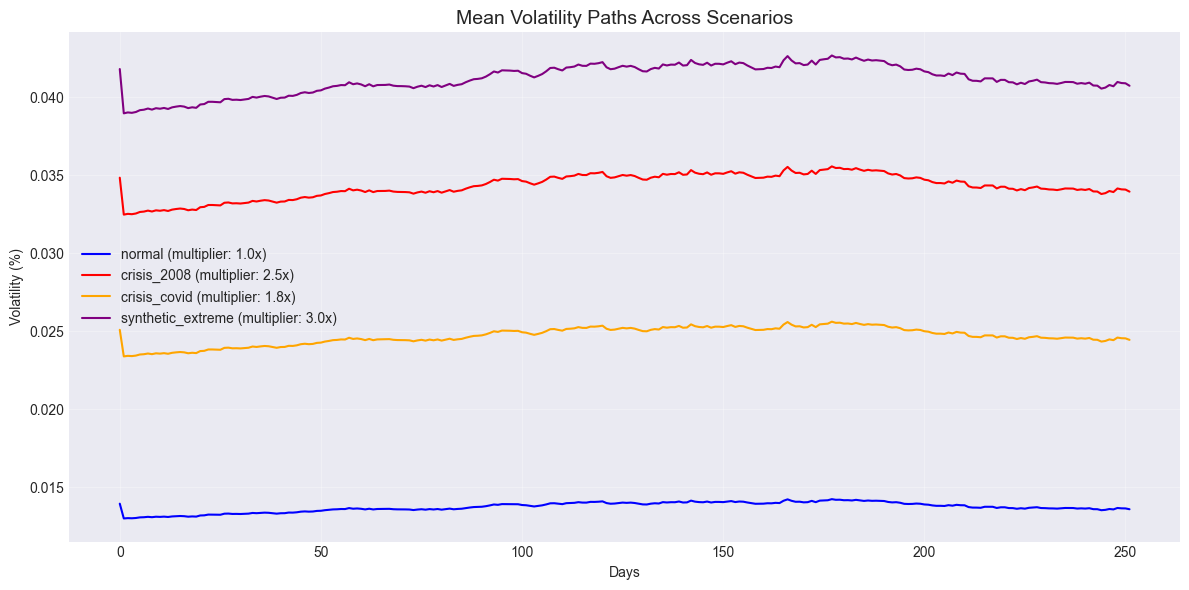

In [70]:
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['blue', 'red', 'orange', 'purple']
for idx, (name, data) in enumerate(all_paths.items()):
    mean_vol = data['volatility'].mean(axis=0)
    ax.plot(mean_vol, label=f"{name} (multiplier: {scenarios[name]['shock_multiplier']}x)", 
            color=colors[idx], linewidth=1.5)

ax.set_title('Mean Volatility Paths Across Scenarios', fontsize=14)
ax.set_xlabel('Days')
ax.set_ylabel('Volatility (%)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/figures/mc_volatility_comparison.png', dpi=150)
plt.show()

/var/folders/x8/_mq2nwzn4x5_6w2mj59szrb40000gn/T/ipykernel_8355/756730755.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True)


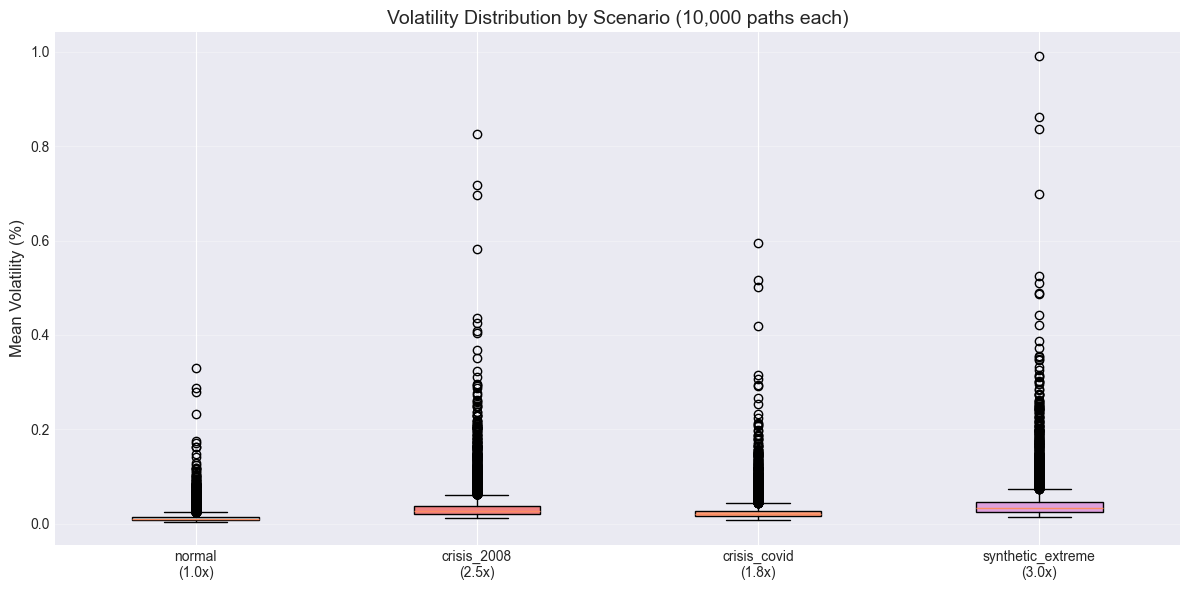

In [71]:
fig, ax = plt.subplots(figsize=(12, 6))

# Create data for box plot
box_data = []
box_labels = []
for name, data in all_paths.items():
    # Take mean volatility across days for each path
    mean_vol_per_path = data['volatility'].mean(axis=1)
    box_data.append(mean_vol_per_path)
    box_labels.append(f"{name}\n({scenarios[name]['shock_multiplier']}x)")

# Create box plot
bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True)

# Customize colors
colors_list = ['lightblue', 'lightcoral', 'lightsalmon', 'plum']
for patch, color in zip(bp['boxes'], colors_list):
    patch.set_facecolor(color)

ax.set_title('Volatility Distribution by Scenario (10,000 paths each)', fontsize=14)
ax.set_ylabel('Mean Volatility (%)', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../results/figures/mc_volatility_boxplot.png', dpi=150)
plt.show()

In [72]:
# Create directory if it doesn't exist
Path('../data/simulated').mkdir(parents=True, exist_ok=True)

# Save each scenario
for name, data in all_paths.items():
    np.save(f'../data/simulated/mc_returns_{name}.npy', data['returns'])
    np.save(f'../data/simulated/mc_volatility_{name}.npy', data['volatility'])
    print(f"✅ Saved: mc_returns_{name}.npy and mc_volatility_{name}.npy")

print("\n" + "="*60)
print("ALL FILES SAVED")
print("="*60)
print("Location: ../data/simulated/")
print("\nFiles:")
for name in all_paths.keys():
    print(f"  - mc_returns_{name}.npy")
    print(f"  - mc_volatility_{name}.npy")

✅ Saved: mc_returns_normal.npy and mc_volatility_normal.npy
✅ Saved: mc_returns_crisis_2008.npy and mc_volatility_crisis_2008.npy
✅ Saved: mc_returns_crisis_covid.npy and mc_volatility_crisis_covid.npy
✅ Saved: mc_returns_synthetic_extreme.npy and mc_volatility_synthetic_extreme.npy

ALL FILES SAVED
Location: ../data/simulated/

Files:
  - mc_returns_normal.npy
  - mc_volatility_normal.npy
  - mc_returns_crisis_2008.npy
  - mc_volatility_crisis_2008.npy
  - mc_returns_crisis_covid.npy
  - mc_volatility_crisis_covid.npy
  - mc_returns_synthetic_extreme.npy
  - mc_volatility_synthetic_extreme.npy


In [73]:
print("\n" + "="*70)
print("MONTE CARLO SIMULATION SUMMARY")
print("="*70)

summary_data = []

for name, data in all_paths.items():
    returns = data['returns']
    volatility = data['volatility']
    
    summary_data.append({
        'Scenario': name.upper(),
        'Multiplier': scenarios[name]['shock_multiplier'],
        'Mean Return %': returns.mean() * 100,
        'Std Return %': returns.std() * 100,
        'Mean Vol %': volatility.mean(),
        'Max Vol %': volatility.max(),
        'Min Vol %': volatility.min()
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

print("\n" + "="*70)
print("✅ Monte Carlo simulation complete!")
print("Next step: Feed these paths into your LSTM model")
print("="*70)


MONTE CARLO SIMULATION SUMMARY
         Scenario  Multiplier  Mean Return %  Std Return %  Mean Vol %  Max Vol %  Min Vol %
           NORMAL         1.0      -0.003426     11.694525    0.013724   1.352481   0.002254
      CRISIS_2008         2.5      -0.005417     18.490668    0.034311   3.381203   0.005636
     CRISIS_COVID         1.8      -0.004597     15.689852    0.024704   2.434466   0.004058
SYNTHETIC_EXTREME         3.0      -0.005934     20.255512    0.041173   4.057443   0.006763

✅ Monte Carlo simulation complete!
Next step: Feed these paths into your LSTM model
